In [46]:
import torch

import numpy as np
import matplotlib.pyplot as plt

In [47]:
import torch.nn as nn

In [48]:
x = torch.linspace(1,50,50).reshape(-1,1)

In [49]:
# x

In [50]:
torch.manual_seed(71)
e = torch.randint(-8,9,(50,1),dtype=torch.float)

In [51]:
# e

In [52]:
y = 2*x + 1 + e

In [53]:
# y

In [54]:
y.shape

torch.Size([50, 1])

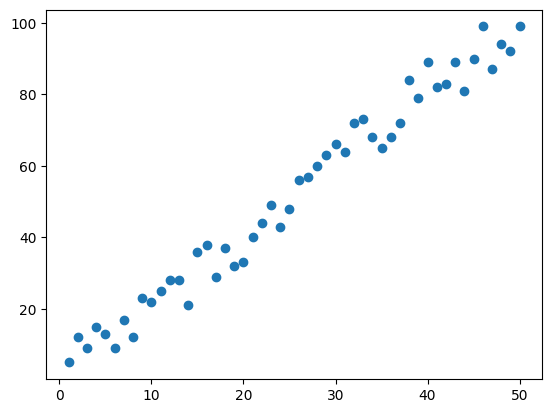

In [55]:
plt.scatter(x.numpy(),y.numpy())

In [56]:
torch.manual_seed(59)
model = nn.Linear(in_features=1,out_features=1)

print(model.weight)
print(model.bias)

Parameter containing:
tensor([[0.1060]], requires_grad=True)
Parameter containing:
tensor([0.9638], requires_grad=True)


In [57]:
class Model(nn.Module):
    def __init__(self,in_features,out_features):
        super().__init__()
        self.linear = nn.Linear(in_features,out_features)

    def forward(self,x):
        y_pred = self.linear(x)
        return y_pred

In [58]:
torch.manual_seed(59)
model = Model(1,1)

print(model.linear.weight)
print(model.linear.bias)

Parameter containing:
tensor([[0.1060]], requires_grad=True)
Parameter containing:
tensor([0.9638], requires_grad=True)


In [59]:
for name, param in model.named_parameters():
    print(name, '\t',param.item())

linear.weight 	 0.10597813129425049
linear.bias 	 0.9637961387634277


In [60]:
xF = torch.Tensor([2.0])
print(model.forward(xF))

tensor([1.1758], grad_fn=<ViewBackward0>)


In [61]:
x1 = np.linspace(0.0,50.0,50)

In [62]:
x1

array([ 0.        ,  1.02040816,  2.04081633,  3.06122449,  4.08163265,
        5.10204082,  6.12244898,  7.14285714,  8.16326531,  9.18367347,
       10.20408163, 11.2244898 , 12.24489796, 13.26530612, 14.28571429,
       15.30612245, 16.32653061, 17.34693878, 18.36734694, 19.3877551 ,
       20.40816327, 21.42857143, 22.44897959, 23.46938776, 24.48979592,
       25.51020408, 26.53061224, 27.55102041, 28.57142857, 29.59183673,
       30.6122449 , 31.63265306, 32.65306122, 33.67346939, 34.69387755,
       35.71428571, 36.73469388, 37.75510204, 38.7755102 , 39.79591837,
       40.81632653, 41.83673469, 42.85714286, 43.87755102, 44.89795918,
       45.91836735, 46.93877551, 47.95918367, 48.97959184, 50.        ])

In [63]:
w1 = 0.10597813129425049
b1 = 0.9637961387634277


In [64]:
y1 = w1 * x1 + b1

In [65]:
y1

array([0.96379614, 1.07193709, 1.18007804, 1.28821899, 1.39635994,
       1.50450089, 1.61264184, 1.72078279, 1.82892374, 1.93706469,
       2.04520564, 2.15334659, 2.26148754, 2.36962849, 2.47776944,
       2.58591039, 2.69405134, 2.80219229, 2.91033324, 3.01847419,
       3.12661514, 3.2347561 , 3.34289705, 3.451038  , 3.55917895,
       3.6673199 , 3.77546085, 3.8836018 , 3.99174275, 4.0998837 ,
       4.20802465, 4.3161656 , 4.42430655, 4.5324475 , 4.64058845,
       4.7487294 , 4.85687035, 4.9650113 , 5.07315225, 5.1812932 ,
       5.28943415, 5.3975751 , 5.50571605, 5.613857  , 5.72199795,
       5.8301389 , 5.93827985, 6.0464208 , 6.15456175, 6.2627027 ])

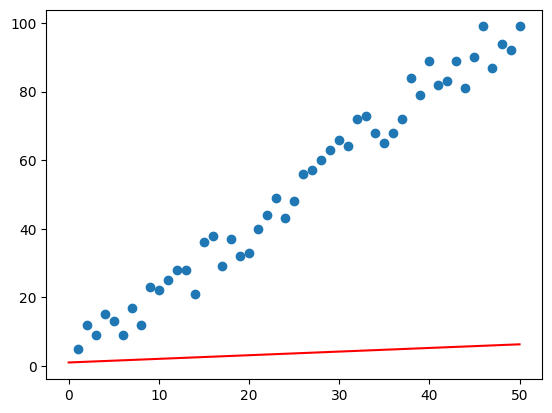

In [66]:
plt.scatter(x.numpy(),y.numpy())
plt.plot(x1,y1,'r')

In [68]:
# need loss function for better results
criterion = nn.MSELoss()

In [71]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.001)

In [81]:
epochs = 50
losses = []
for i in range(epochs):
    i = i + 1

    # predicting on the forward pass
    y_pred = model.forward(x)

    # calculate our loss (error)
    loss = criterion(y_pred,y)

    # record error
    losses.append(loss)

    print(f"epoch {i} loss: {loss.item()} weight: {model.linear.weight.item()} bias: {model.linear.bias.item()}")

    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

epoch 1 loss: 21.03310775756836 weight: 1.982771635055542 bias: 1.0910162925720215
epoch 2 loss: 21.032621383666992 weight: 1.9827508926391602 bias: 1.0917129516601562
epoch 3 loss: 21.032142639160156 weight: 1.9827302694320679 bias: 1.0924092531204224
epoch 4 loss: 21.031654357910156 weight: 1.982709527015686 bias: 1.0931051969528198
epoch 5 loss: 21.031171798706055 weight: 1.9826890230178833 bias: 1.0938007831573486
epoch 6 loss: 21.030683517456055 weight: 1.9826679229736328 bias: 1.0944960117340088
epoch 7 loss: 21.03020668029785 weight: 1.9826477766036987 bias: 1.0951910018920898
epoch 8 loss: 21.029722213745117 weight: 1.9826267957687378 bias: 1.0958856344223022
epoch 9 loss: 21.029237747192383 weight: 1.9826064109802246 bias: 1.096579909324646
epoch 10 loss: 21.028757095336914 weight: 1.9825855493545532 bias: 1.097273826599121
epoch 11 loss: 21.028276443481445 weight: 1.98256516456604 bias: 1.0979673862457275
epoch 12 loss: 21.027793884277344 weight: 1.9825443029403687 bias: 1.09

In [83]:
losses

[tensor(21.0331, grad_fn=<MseLossBackward0>),
 tensor(21.0326, grad_fn=<MseLossBackward0>),
 tensor(21.0321, grad_fn=<MseLossBackward0>),
 tensor(21.0317, grad_fn=<MseLossBackward0>),
 tensor(21.0312, grad_fn=<MseLossBackward0>),
 tensor(21.0307, grad_fn=<MseLossBackward0>),
 tensor(21.0302, grad_fn=<MseLossBackward0>),
 tensor(21.0297, grad_fn=<MseLossBackward0>),
 tensor(21.0292, grad_fn=<MseLossBackward0>),
 tensor(21.0288, grad_fn=<MseLossBackward0>),
 tensor(21.0283, grad_fn=<MseLossBackward0>),
 tensor(21.0278, grad_fn=<MseLossBackward0>),
 tensor(21.0273, grad_fn=<MseLossBackward0>),
 tensor(21.0268, grad_fn=<MseLossBackward0>),
 tensor(21.0264, grad_fn=<MseLossBackward0>),
 tensor(21.0259, grad_fn=<MseLossBackward0>),
 tensor(21.0254, grad_fn=<MseLossBackward0>),
 tensor(21.0249, grad_fn=<MseLossBackward0>),
 tensor(21.0244, grad_fn=<MseLossBackward0>),
 tensor(21.0240, grad_fn=<MseLossBackward0>),
 tensor(21.0235, grad_fn=<MseLossBackward0>),
 tensor(21.0230, grad_fn=<MseLossB

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

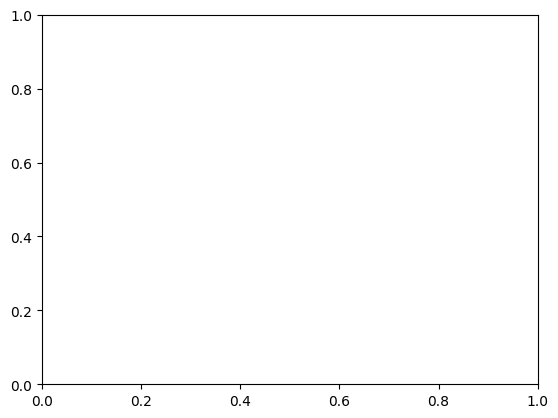

In [82]:
plt.plot(range(epochs),losses)
plt.ylabel('MSE LOSS')
plt.xlabel('Epoch ')

In [87]:
X = np.linspace(0.0,50.0,50)
current_weight = model.linear.weight.item()
current_bias = model.linear.bias.item()

predicted_y = current_weight*x + current_bias

In [88]:
predicted_y

array([  1.12543678,   3.14762958,   5.16982237,   7.19201517,
         9.21420796,  11.23640076,  13.25859355,  15.28078634,
        17.30297914,  19.32517193,  21.34736473,  23.36955752,
        25.39175032,  27.41394311,  29.43613591,  31.4583287 ,
        33.48052149,  35.50271429,  37.52490708,  39.54709988,
        41.56929267,  43.59148547,  45.61367826,  47.63587106,
        49.65806385,  51.68025664,  53.70244944,  55.72464223,
        57.74683503,  59.76902782,  61.79122062,  63.81341341,
        65.83560621,  67.857799  ,  69.87999179,  71.90218459,
        73.92437738,  75.94657018,  77.96876297,  79.99095577,
        82.01314856,  84.03534136,  86.05753415,  88.07972694,
        90.10191974,  92.12411253,  94.14630533,  96.16849812,
        98.19069092, 100.21288371])

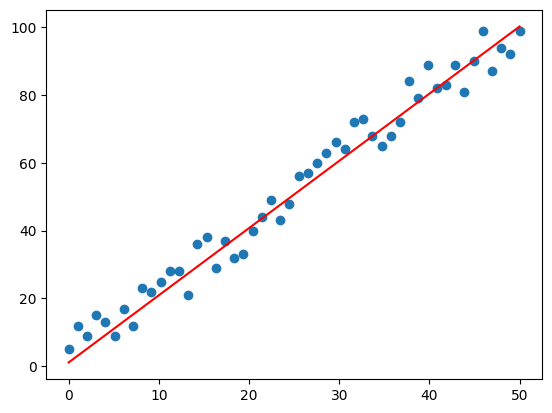

In [93]:
plt.scatter(X, y.numpy())
plt.plot(x, predicted_y, 'r')